
# ERT field data with Topography

> Solving the RkATi process!!!

First adding our imports.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pygimli as pg
from pygimli.physics import ert
import os

Now call the data file and load it.

In [2]:
os.chdir(r'C:\Users\sydne\git\erth590\erth590_fieldschool_ert')
print(f'Directory: {os.getcwd()}')  # shows current working directory
os.makedirs(r"figures/d1", exist_ok=True)

filename = r'data\d1\Wenner_1-2026-05-22-100211.dat'
data = ert.load(filename)
print(data)

23/05/26 - 14:12:38 - pyGIMLi - INFO - could not read unified data format for ERT ... try res2dinv


Directory: C:\Users\sydne\git\erth590\erth590_fieldschool_ert
Data: Sensors: 81 data: 445, nonzero entries: ['a', 'b', 'm', 'n', 'r', 'valid']


Now we read topography from a file and apply to the electrode positions.
- typically topography is in the ERT .dat file, but for my code, I have it as a seperate .txt file. 

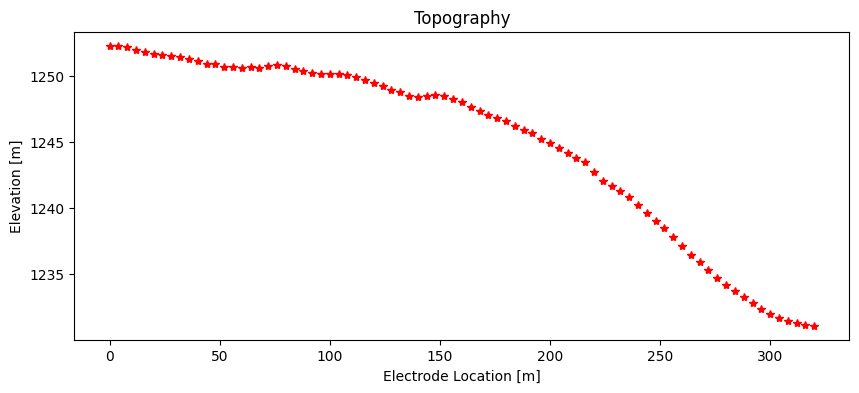

In [3]:
topo = []

topo_file = r'data\d1\topo_day1.txt'

with open(topo_file) as f: 
    next(f)  # skip header line
    for line in f:
        line = line.strip()
        parts = line.split()  # split using whitespace
        if len(parts) == 2:  # if data has 2 columns it is topo data so add to the list
            topo.append([float(parts[0]), float(parts[1])])

topo = np.array(topo)  # convert to numpy array

x_elec = pg.x(data)  # get x pos of all electrodes

z_elec = np.interp(x_elec, topo[:,0], topo[:,1])  # interpolate topo at each electrode

x_elec = np.array(pg.x(data))  # convert RVector to numpy

# now we ensure topo covers all electrodes at both ends
if topo[0,0] > x_elec.min():  # if topo is to the right of (after) electrode
    topo = np.vstack(([x_elec.min(), topo[0,1]], topo))
if topo[-1,0] < x_elec.max():  # if topo is to the left of (before) electrode
    topo = np.vstack((topo, [x_elec.max(), topo[-1,1]]))

# second interp of topo at electrode positions
z_interp = np.interp(x_elec, topo[:,0], topo[:,1])

# print(f'z_interp: {z_interp}')

# set electrode positions in data

data.setSensorPositions(pg.PosVector(np.c_[x_elec, z_interp]))  # combine into 2D array, convert to gimli pos vector, and update elec pos in ERT dataset

# plot to check
fig, ax = plt.subplots(figsize=(10,4)) 
ax.plot(x_elec, z_interp, 'r*')
ax.set_xlabel('Electrode Location [m]')
ax.set_ylabel('Elevation [m]')
ax.set_title('Topography')

fig.savefig(r"figures/d1/topography.png", dpi=400, bbox_inches='tight') 
plt.show()

Now we compute geometric factors (K) in order to computer raw resistance into apparent resistivity later.

In [4]:
k0 = ert.createGeometricFactors(data)  # analytical; assumes simple geometry
data['k'] = ert.createGeometricFactors(data, numerical=True)  # numerical; solves forward PDE

23/05/26 - 14:12:39 - pyGIMLi - INFO - Cache c:\Users\sydne\anaconda3\envs\pg\Lib\site-packages\pygimli\physics\ert\ert.py:createGeometricFactors restored (0.0s x 5): C:\Users\sydne\AppData\Roaming\pygimli\Cache\13617193006800534100
23/05/26 - 14:12:39 - pyGIMLi - INFO - Cache c:\Users\sydne\anaconda3\envs\pg\Lib\site-packages\pygimli\physics\ert\ert.py:createGeometricFactors restored (8.3s x 5): C:\Users\sydne\AppData\Roaming\pygimli\Cache\16122809225802198537


Diagnostic plot to show the ratio of analytical to numerical geometric factors as a pseudosection.
-  if the pseudosection is mostly white, topography does not impact that survey line a ton.
- if red, topography is inflating apparent resistivity
- if blue, topography is reducing apparent resistivity

If the topography effect on data looks strange (ie. no color bar, axes titles) just rerun and it'll work!!!

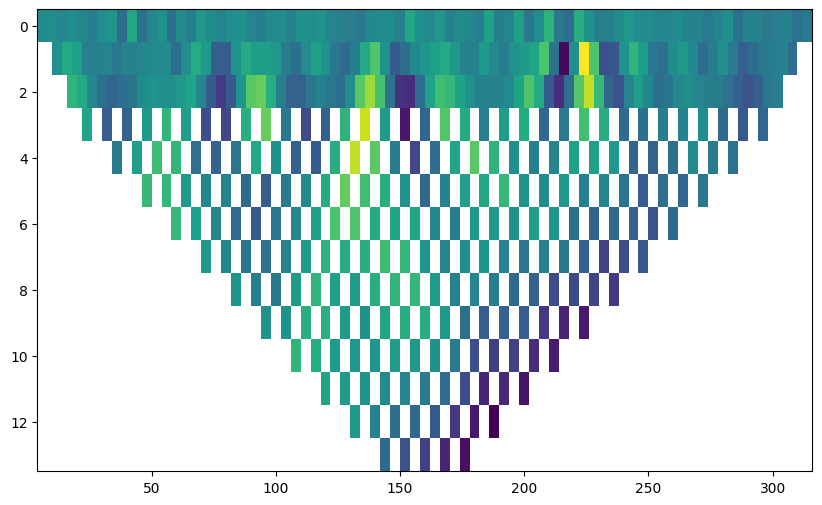

c:\Users\sydne\anaconda3\envs\pg\Lib\site-packages\pygimli\viewer\mpl\colorbar.py:319: UserWarning: Adding colorbar to a different Figure <Figure size 1000x600 with 2 Axes> than <Figure size 640x480 with 0 Axes> which fig.colorbar is called on.
  cbar = cbarTarget.colorbar(gci, cax=cax, orientation=orientation)


<Figure size 640x480 with 0 Axes>

In [5]:
fig, ax = plt.subplots(figsize=(10, 6))
_ = ert.showData(data, 
                 vals=k0/ data['k'],  # quantifies the topography effect
                 ax=ax,
                 label='Topography effect', xlabel='Distance [m]', ylabel='Pseudo-depth',
                 cMin=0.8, cMax=1.2,  # color limits
                 logScale=True, 
                 cMap="bwr"  # blue-white-red colormap
)

ax.set_title('Topography Effect on Data');

fig.savefig(r"figures/d1/topo_effect_on_data_wen.png", dpi=400, bbox_inches='tight')


Now we actually compute apparent resistivity.

In [6]:
data['rhoa'] = data['r'] * data['k']  # uses numerical k; converts measured resistances to apparent resist

# edit impossible negative or zero values
# data['rhoa'][data['rhoa'] <= 0] = 1e-6
data['rhoa'][data['rhoa'] <= 0] = 1
data['rhoa'][data['rhoa'] >= 500] = 500

Now we shall do a data error estimate!

Data: Sensors: 81 data: 445, nonzero entries: ['a', 'b', 'err', 'k', 'm', 'n', 'r', 'rhoa', 'valid']


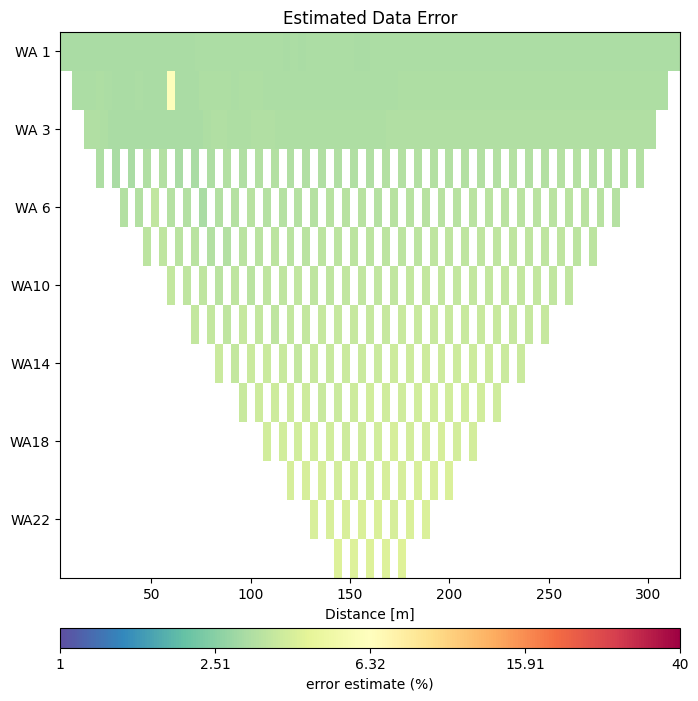

In [7]:
data.estimateError(relativeError=0.03, absoluteUError=5e-5)

data.remove(data['err'] > 0.8)  # removing points with 80% or higher error
print(data)  # check how many points are left

fig, ax = plt.subplots(figsize=(8,8))
_ = data.show( data['err']*100, ax=ax,
    label='error estimate (%)', xlabel='Distance [m]',
    cMin=1, cMax=40)

ax.set_title('Estimated Data Error');

fig.savefig(r"figures/d1/est_data_error_wen.png", dpi=400, bbox_inches='tight')


Now we want X^2 ~ 1 and dPhi (delt obj) as low as possible

> optimal wenner parameters (5m)
- lam: 25
- MCS: 5
- depth: 30
> optimal DD parameters (8m)
- lam: 25
- MCS: 10
- depth: 40

In [8]:
mgr = ert.ERTManager(data)  # inversion manager

mod = mgr.invert(data, lam=10, verbose=True,  # lam: smoothness,    DX: horizontal cells factor
                 paraDX=0.3, paraMaxCellSize=2, paraDepth=5, quality=33.6)

23/05/26 - 14:12:41 - pyGIMLi - INFO - Found 2 regions.
23/05/26 - 14:12:41 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
23/05/26 - 14:12:41 - pyGIMLi - INFO - Found 2 regions.
23/05/26 - 14:12:41 - pyGIMLi - INFO - Region with smallest marker set to background (marker=1)
23/05/26 - 14:12:41 - pyGIMLi - INFO - Creating forward mesh from region infos.
23/05/26 - 14:12:41 - pyGIMLi - INFO - Creating refined mesh (H2) to solve forward task.
23/05/26 - 14:12:41 - pyGIMLi - INFO - Mesh for forward task: Mesh: Nodes: 16325 Cells: 32040 Boundaries: 24334
23/05/26 - 14:12:42 - pyGIMLi - INFO - Use median(data values)=28.31303235346825
23/05/26 - 14:12:42 - pyGIMLi - INFO - Created startmodel from forward operator:5863, min/max=28.313032/28.313032
23/05/26 - 14:12:42 - pyGIMLi - INFO - Starting inversion.


fop: <pygimli.physics.ert.ertModelling.ERTModelling object at 0x00000218F89F5850>
Data transformation: Logarithmic LU transform, lower bound 0.0, upper bound 0.0
Model transformation: Logarithmic transform
min/max (data): 1/500
min/max (error): 3%/6.12%
min/max (start model): 28.31/28.31
--------------------------------------------------------------------------------
inv.iter 0 ... chi² =  698.82
--------------------------------------------------------------------------------
inv.iter 1 ... chi² =  521.59 (dPhi = 25.13%) lam: 10.0
--------------------------------------------------------------------------------
inv.iter 2 ... chi² =  305.20 (dPhi = 39.10%) lam: 10.0
--------------------------------------------------------------------------------
inv.iter 3 ... chi² =  209.52 (dPhi = 30.79%) lam: 10.0
--------------------------------------------------------------------------------
inv.iter 4 ... chi² =  143.24 (dPhi = 30.38%) lam: 10.0
----------------------------------------------------

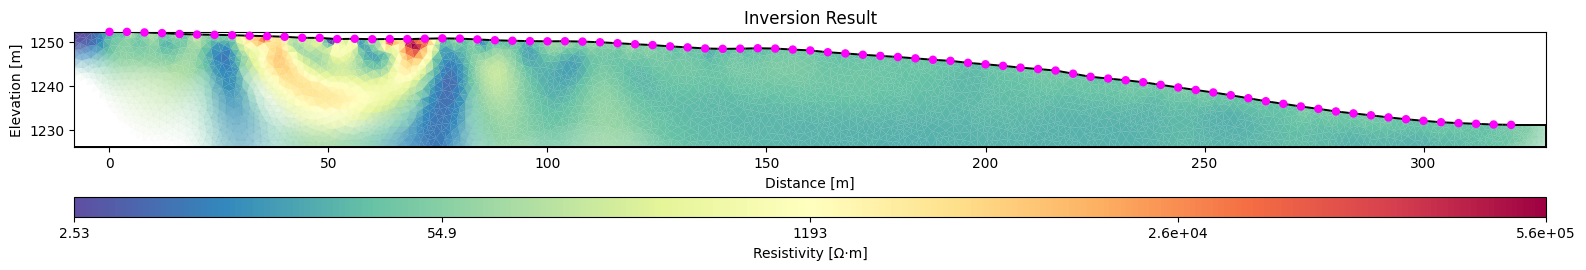

In [9]:
fig, ax = plt.subplots(figsize=(16, 16))
ax, cb = mgr.showResult(ax=ax, cMap = 'Spectral_r')
cb.set_label("Resistivity [Ω·m]") 

ax.set_title("Inversion Result") 
ax.set_xlabel("Distance [m]")
ax.set_ylabel("Elevation [m]")

fig.savefig(r"figures\d1\1inversion_result_wen.png", dpi=400, bbox_inches="tight")

Now we're gonna constrain the resistivities a teeny tiny bit.....

> wenner: cMin=5, cMax=4000

> DD: cMin=15, cMax=500

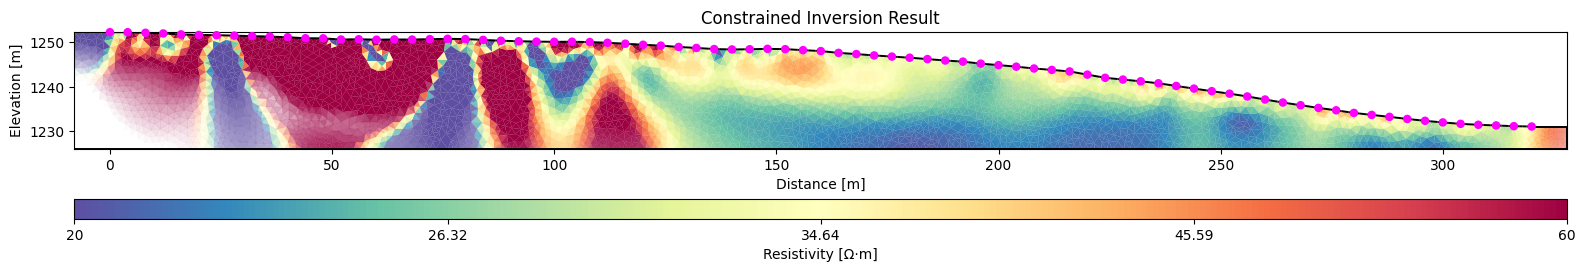

In [14]:
fig, ax = plt.subplots(figsize=(16, 16))
ax, cb = mgr.showResult(mod, ax=ax, cMin=20, cMax=60, cMap='Spectral_r',logScale=True)

cb.set_label("Resistivity [Ω·m]") 

ax.set_xlabel("Distance [m]")
ax.set_ylabel("Elevation [m]")
ax.set_title('Constrained Inversion Result')

fig.savefig(r"figures/d1/2constr_inver_wen.png", dpi=400, bbox_inches='tight')